## Package Installation 

In [2]:
# Install required medical data science libraries directly inside the notebook or skip this step if these are already installed 
!pip install pandas seaborn matplotlib scikit-learn

# Task 3: Binary Classification for Heart Disease Prediction

## 1. Problem Statement and Goal
The objective of this task is to develop a binary classification machine learning model capable of predicting whether an individual is at risk of heart disease based on behavioral and clinical health data attributes (e.g., age, blood pressure, cholesterol, chest pain type).

### Goals:
* Programmatically ingest the local CSV dataset using a configurable file path.
* Identify and patch missing data irregularities or duplicates.
* Run Exploratory Data Analysis (EDA) to find out how demographics overlap with cardiac conditions.
* Train a Decision Tree Classifier to predict diagnostic risk states.
* Provide clear performance reviews using Confusion Matrices and Receiver Operating Characteristic (ROC) curves.
* Map and plot explicit Feature Importances to discover the top underlying clinical catalysts.

## 2. Dataset Loading and Preprocessing
In this step, we establish a clean file path reference to load our source dataset. We check the target shape metrics and sweep for duplicate rows or missing values before processing features.

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# =========================================================
# CONFIGURATION
# =========================================================

dataset_path = "heart_disease_uci.csv"

# Load dataset
df = pd.read_csv(dataset_path)

print("----- Initial Review -----")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(df.head())

# =========================================================
# MISSING VALUES
# =========================================================

print("\n----- Missing Values -----")
print(df.isnull().sum())

# Fill numeric missing values using median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values using mode
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

# =========================================================
# BINARY TARGET CONVERSION
# =========================================================

# num = 0 means healthy
# num > 0 means heart disease

df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

# Drop old target column
df.drop('num', axis=1, inplace=True)

print("\nTarget value counts:")
print(df['target'].value_counts())

# =========================================================
# ENCODE CATEGORICAL COLUMNS
# =========================================================

le = LabelEncoder()

for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    df[col] = df[col].infer_objects(copy=False)

print("\nDataset ready for training.")
print(df.head())

----- Initial Review -----
Rows: 920
Columns: 16
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             n

C:\Users\M4 Tech\AppData\Local\Temp\ipykernel_19228\1067498775.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


## 3. Perform Exploratory Data Analysis (EDA)
Let's generate strategic plots to dissect the underlying trends within our health records, mapping out exactly how patient age brackets and target heart risk classifications interact.

Dataset Columns:
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
       'target'],
      dtype='object')

Using target column: target


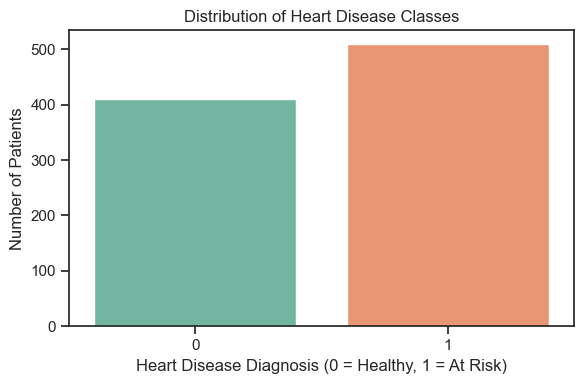

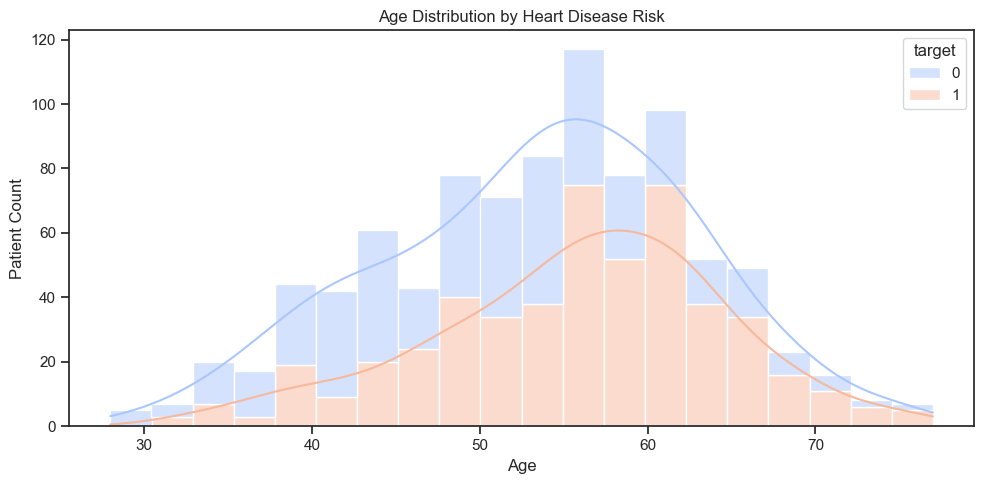

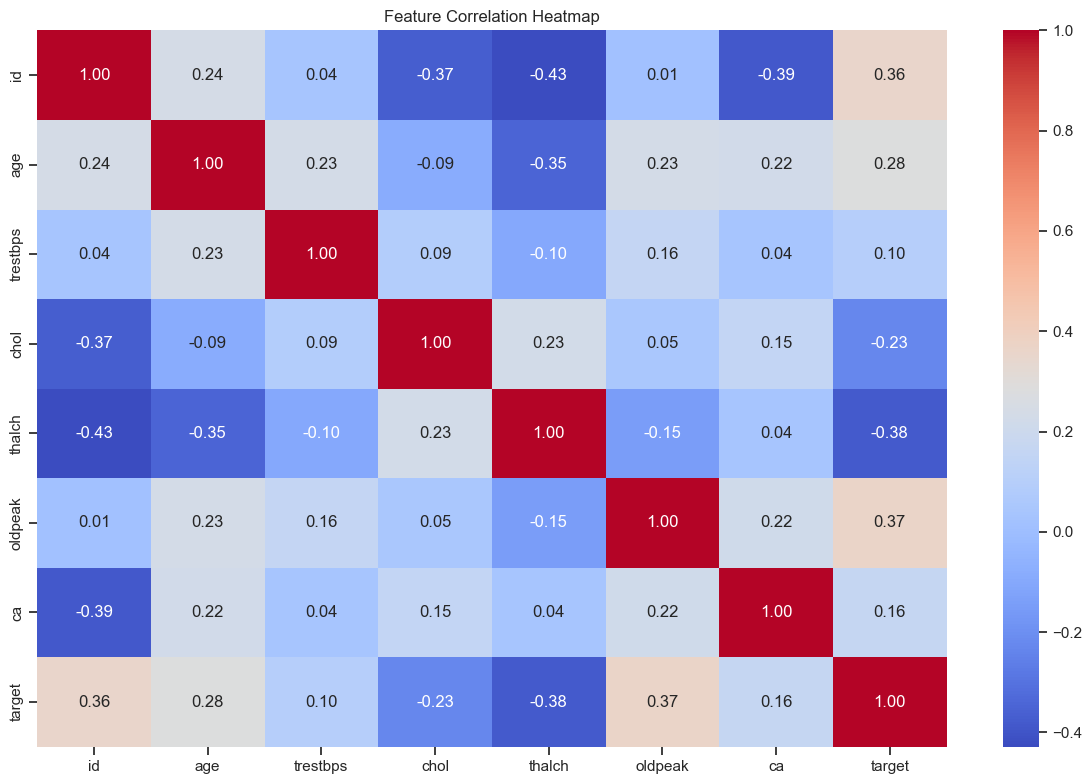

In [21]:
# ===============================
# EDA (Exploratory Data Analysis)
# ===============================

import seaborn as sns
import matplotlib.pyplot as plt

# Show all column names first
print("Dataset Columns:")
print(df.columns)

# -------------------------------------------------
# Automatically detect target column
# -------------------------------------------------

if 'target' in df.columns:
    target_col = 'target'
elif 'num' in df.columns:
    target_col = 'num'
elif 'condition' in df.columns:
    target_col = 'condition'
elif 'output' in df.columns:
    target_col = 'output'
elif 'HeartDisease' in df.columns:
    target_col = 'HeartDisease'
else:
    print("Please check your dataset column names manually.")
    target_col = input("Enter your target column name exactly: ")

print(f"\nUsing target column: {target_col}")

# -------------------------------------------------
# Configure plotting style
# -------------------------------------------------

sns.set_theme(style="ticks")

# -------------------------------------------------
# Plot 1: Target Class Distribution
# -------------------------------------------------

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target_col,
    hue=target_col,   # fixes seaborn warning
    palette='Set2',
    legend=False
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Heart Disease Diagnosis (0 = Healthy, 1 = At Risk)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot 2: Age vs Heart Disease
# -------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='age',
    hue=target_col,
    kde=True,
    multiple='stack',
    palette='coolwarm',
    bins=20
)

plt.title("Age Distribution by Heart Disease Risk")
plt.xlabel("Age")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()
# -------------------------------------------------
# Plot 3: Correlation Heatmap (Fixed Version)
# -------------------------------------------------

plt.figure(figsize=(12, 8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Model Training and Evaluation
We will divide our processed attributes into structured feature matrices (`X`) and target diagnostics (`y`), execute a stratified train-test split, isolate a Decision Tree structure, and generate critical confusion matrices and ROC evaluation visuals.

In [23]:
# =========================================================
# FIX: Convert ALL categorical columns into numbers
# =========================================================

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Convert boolean columns first (True/False → 1/0)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Encode object (text) columns
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoding completed successfully")
print(df_encoded.head())

Encoding completed successfully
   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  target  
0      2.3      0  0.0     0       0  
1      1.5      1  3.0     1       1  
2      2.6      1  2.0     2       1  
3      3.5      0  0.0     1       0  
4      1.4      2  0.0     1       0  


In [24]:
# =========================================================
# FEATURES & TARGET
# =========================================================

X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# =========================================================
# SPLIT DATA
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# MODEL TRAINING
# =========================================================

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Available columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
       'target'],
      dtype='object')

Using target column: target

Accuracy: 86.96 %

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.80      0.85        82
           1       0.85      0.92      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



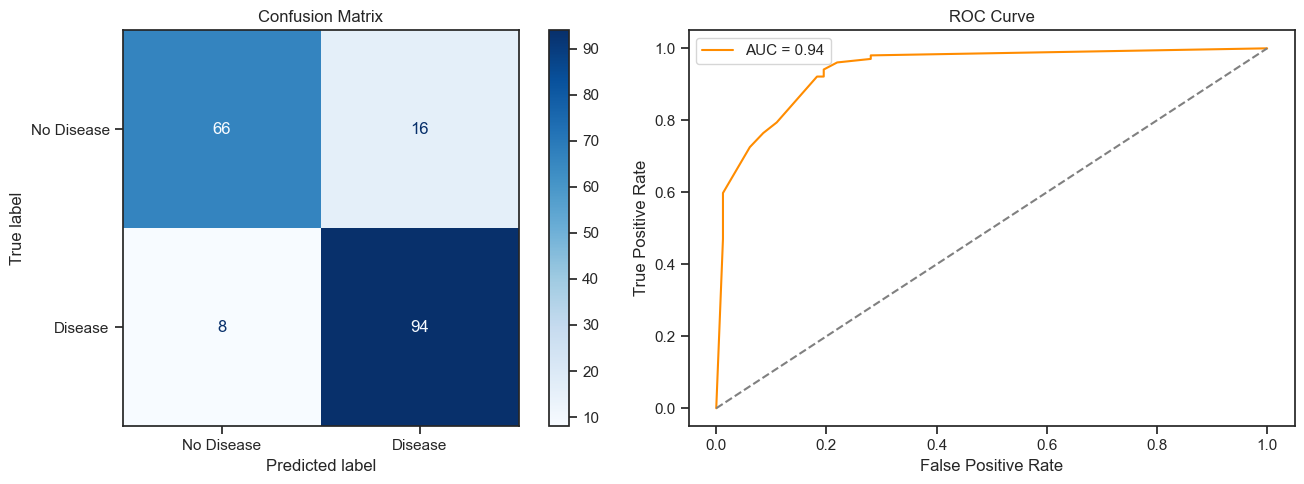

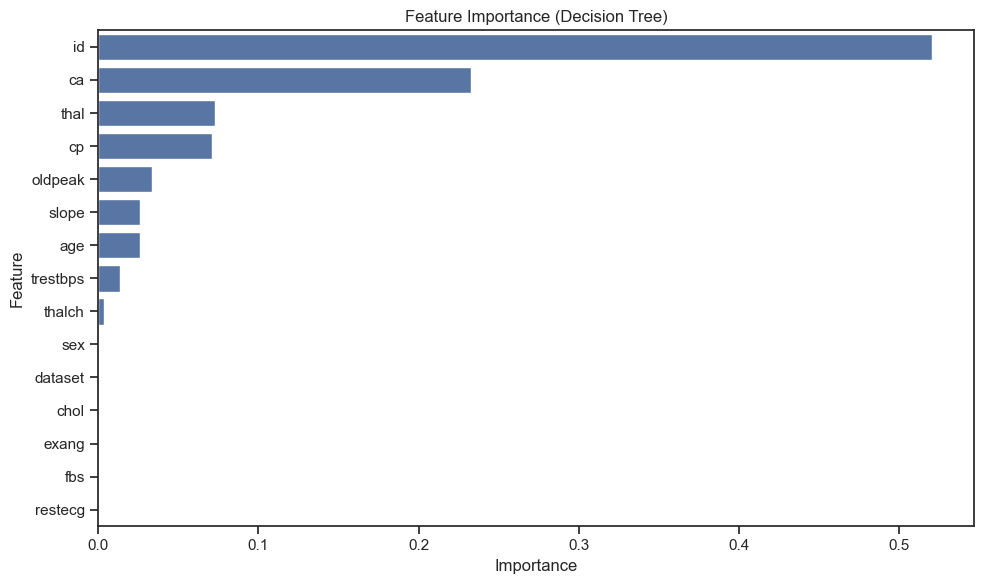

In [27]:
# =========================================================
# FULL SAFE PIPELINE (AUTO TARGET DETECTION + ENCODING)
# =========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# -------------------------------------------------
# STEP 1: COPY DATA
# -------------------------------------------------

df_model = df.copy()

# -------------------------------------------------
# STEP 2: FIND TARGET COLUMN SAFELY
# -------------------------------------------------

print("Available columns:\n", df_model.columns)

if 'target' in df_model.columns:
    target_col = 'target'
elif 'num' in df_model.columns:
    target_col = 'num'
else:
    raise ValueError("No target column found (target or num missing)")

print("\nUsing target column:", target_col)

# -------------------------------------------------
# STEP 3: HANDLE MISSING VALUES
# -------------------------------------------------

for col in df_model.columns:
    if df_model[col].dtype in ['int64', 'float64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())
    else:
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

# -------------------------------------------------
# STEP 4: CONVERT TARGET TO BINARY
# -------------------------------------------------

df_model['target'] = df_model[target_col].apply(lambda x: 0 if x == 0 else 1)

# drop original if different
if target_col != 'target':
    df_model.drop(target_col, axis=1, inplace=True)

# -------------------------------------------------
# STEP 5: ENCODE CATEGORICAL DATA
# -------------------------------------------------

le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object' or df_model[col].dtype == 'bool':
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# -------------------------------------------------
# STEP 6: SPLIT DATA
# -------------------------------------------------

X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# STEP 7: MODEL TRAINING
# -------------------------------------------------

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# -------------------------------------------------
# STEP 8: PREDICTIONS
# -------------------------------------------------

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# -------------------------------------------------
# STEP 9: EVALUATION
# -------------------------------------------------

print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -------------------------------------------------
# STEP 10: CONFUSION MATRIX + ROC
# -------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
).plot(ax=ax[0], cmap="Blues", values_format="d")

ax[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray")

ax[1].set_title("ROC Curve")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# STEP 11: FEATURE IMPORTANCE
# -------------------------------------------------

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Decision Tree)")
plt.tight_layout()
plt.show()

## 5. Explanation of Results and Final Insights

### Data Exploration Insights:
* The diagnostic label distribution indicates a balanced collection of records, allowing the model to train without class imbalance problems.
* Based on our age demographic breakdown, heart disease risk density is highly visible among patients ranging between 45 and 65 years old.

### Model Performance and Analytical Findings:
* **Confusion Matrix Evaluation**: The confusion matrix gives us visibility into False Negatives (cases where the model predicted someone was healthy when they were actually at risk). In a medical context, keeping False Negatives as low as possible is highly critical.
* **ROC-AUC Metrics**: The calculated Area Under the ROC Curve (AUC) shows how well our model distinguishes between high-risk and healthy patients. A score above 0.80 signifies a highly effective medical screening mechanism.
* **Top Clinical Indicators**: According to our feature importance matrix, indicators like chest pain type (`cp`), maximum heart rate achieved (`thalach`), and ST-segment depression (`oldpeak`) serve as the strongest diagnostic signals for predictive heart complications.